In [2]:
import os
import cv2
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
def get_box_data(index, hdf5_data):
    """Trích xuất tọa độ và nhãn của ảnh tại chỉ mục (index) từ cấu trúc HDF5"""
    meta_data = dict()
    meta_data['height'] = []
    meta_data['label'] = []
    meta_data['left'] = []
    meta_data['top'] = []
    meta_data['width'] = []
    
    box = hdf5_data['digitStruct']['bbox'][index][0]
    box_data = hdf5_data[box]
    
    if len(box_data['label']) > 1:
        for key in ['height', 'label', 'left', 'top', 'width']:
            attrs = box_data[key]
            for i in range(len(attrs)):
                meta_data[key].append(int(hdf5_data[attrs[i][0]][0][0]))
    else:
        for key in ['height', 'label', 'left', 'top', 'width']:
            meta_data[key].append(int(box_data[key][0][0]))
            
    return meta_data

def get_name(index, hdf5_data):
    """Lấy tên file ảnh chính xác trong digitStruct"""
    name_ref = hdf5_data['digitStruct']['name'][index][0]
    return ''.join([chr(c[0]) for c in hdf5_data[name_ref]])

In [56]:
TRAIN_DIR = '/kaggle/input/datasets/organizations/stanfordu/street-view-house-numbers/train/train'
MAT_FILE = '/kaggle/input/datasets/organizations/stanfordu/street-view-house-numbers/train_digitStruct.mat'
X_train = []
train_bboxes = []
train_labels = []
IMG_SIZE = 64 

with h5py.File(MAT_FILE, 'r') as f:
    num_images = len(f['digitStruct']['bbox'])
    
    sample_size = min(15000, num_images) 
    
    for i in range(sample_size):
        img_name = get_name(i, f)
        img_path = os.path.join(TRAIN_DIR, img_name)
        
        if not os.path.exists(img_path):
            continue
            
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        h_img, w_img = img.shape
        box_data = get_box_data(i, f)
        
        for j in range(len(box_data['label'])):
            lbl = box_data['label'][j]
            if lbl == 10: lbl = 0 # Trong SVHN, số 0 được gán nhãn là 10
                
            top, left = box_data['top'][j], box_data['left'][j]
            width, height = box_data['width'][j], box_data['height'][j]
            
            xmin = max(0, left)
            ymin = max(0, top)
            xmax = min(w_img, left + width)
            ymax = min(h_img, top + height)
            
            # Cắt rộng vùng biên (Padding) để mô hình học context xung quanh chữ số
            pad = 8
            crop_xmin = max(0, xmin - pad)
            crop_ymin = max(0, ymin - pad)
            crop_xmax = min(w_img, xmax + pad)
            crop_ymax = min(h_img, ymax + pad)
            
            crop_img = img[crop_ymin:crop_ymax, crop_xmin:crop_xmax]
            if crop_img.size == 0: continue
                
            # Tính toán tọa độ bbox tương đối (từ 0 đến 1) so với ảnh đã crop
            crop_h, crop_w = crop_img.shape
            bbox_xmin = (xmin - crop_xmin) / crop_w
            bbox_ymin = (ymin - crop_ymin) / crop_h
            bbox_xmax = (xmax - crop_xmin) / crop_w
            bbox_ymax = (ymax - crop_ymin) / crop_h
            
            crop_img_resized = cv2.resize(crop_img, (IMG_SIZE, IMG_SIZE))
            
            X_train.append(crop_img_resized)
            train_bboxes.append([bbox_xmin, bbox_ymin, bbox_xmax, bbox_ymax])
            train_labels.append(lbl)

# Chuyển đổi sang định dạng numpy array phục vụ training
X_train = np.array(X_train, dtype=np.float32) / 255.0
X_train = np.expand_dims(X_train, axis=-1)
train_bboxes = np.array(train_bboxes, dtype=np.float32)
train_labels = np.array(train_labels, dtype=np.int32)

print(f"Hoàn thành tiền xử lý: Đã sẵn sàng {len(X_train)} mẫu chữ số.")

Hoàn thành tiền xử lý: Đã sẵn sàng 32923 mẫu chữ số.


In [61]:
def create_digit_detector_model():
    inputs = layers.Input(shape=(64, 64, 1))
    
    # 1. Định nghĩa khối Data Augmentation
    x = layers.RandomContrast(0.15)(inputs)
    x = layers.RandomZoom(height_factor=(-0.05, 0.1), width_factor=(-0.05, 0.1))(x)
    x = layers.RandomTranslation(height_factor=0.05, width_factor=0.05)(x)

    # Khối tích chập 1
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.1)(x) # Dropout nhẹ trên feature map

    # Khối tích chập 2
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.1)(x)

    # Khối tích chập 3
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.1)(x)

    # Khối Flatten & Dense
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.35)(x) # Tăng dropout từ 0.3 lên 0.4

    # Nhánh 1: Dự đoán vị trí Bounding Box
    bbox_output = layers.Dense(4, activation='sigmoid', name='bounding_box')(x)

    # Nhánh 2: Dự đoán nhãn chữ số (10 classes từ 0-9)
    class_output = layers.Dense(10, activation='softmax', name='class_label')(x)

    model = models.Model(inputs=inputs, outputs=[bbox_output, class_output])
    return model

model = create_digit_detector_model()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_1   │ (None, 64, 64, 1) │          0 │ input_layer_4[0]… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 64, 64, 1) │          0 │ random_contrast_… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 64, 64, 1) │          0 │ random_zoom_1[0]… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │        640 │ random_translati… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_3 │ (None, 32, 32,    │          0 │ max_pooling2d_12… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │     73,856 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_4 │ (None, 16, 16,    │          0 │ max_pooling2d_13… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │    295,168 │ spatial_dropout2… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_5 │ (None, 8, 8, 256) │          0 │ max_pooling2d_14… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16384)     │          0 │ spatial_dropout2

 Total params: 8,767,758 (33.45 MB)

 Trainable params: 8,766,862 (33.44 MB)

 Non-trainable params: 896 (3.50 KB)

In [62]:
losses = {
    'bounding_box': 'mean_squared_error',
    'class_label': 'sparse_categorical_crossentropy'
}

loss_weights = {
    'bounding_box': 2.0,
    'class_label': 1.0
}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=losses,
    loss_weights=loss_weights,
    metrics={'class_label': 'accuracy'}
)

In [63]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, 
    {'bounding_box': train_bboxes, 'class_label': train_labels}, 
    validation_split=0.15, 
    epochs=25, 
    batch_size=64, 
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/25


E0000 00:00:1783937047.114149      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/spatial_dropout2d_3_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


438/438 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - bounding_box_loss: 0.0243 - class_label_accuracy: 0.2944 - class_label_loss: 2.2110 - loss: 2.3808 - val_bounding_box_loss: 0.0124 - val_class_label_accuracy: 0.4197 - val_class_label_loss: 1.6650 - val_loss: 1.8095 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - bounding_box_loss: 0.0119 - class_label_accuracy: 0.5720 - class_label_loss: 1.2215 - loss: 1.3564 - val_bounding_box_loss: 0.0070 - val_class_label_accuracy: 0.6872 - val_class_label_loss: 1.0206 - val_loss: 1.1501 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - bounding_box_loss: 0.0083 - class_label_accuracy: 0.6725 - class_label_loss: 0.9717 - loss: 1.1016 - val_bounding_box_loss: 0.0063 - val_class_label_accuracy: 0.7943 - val_class_label_loss: 0.7214 - val_loss: 0.8503 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - bounding_box_loss: 0.0067 - class_label_accuracy: 0.7273 - class_la

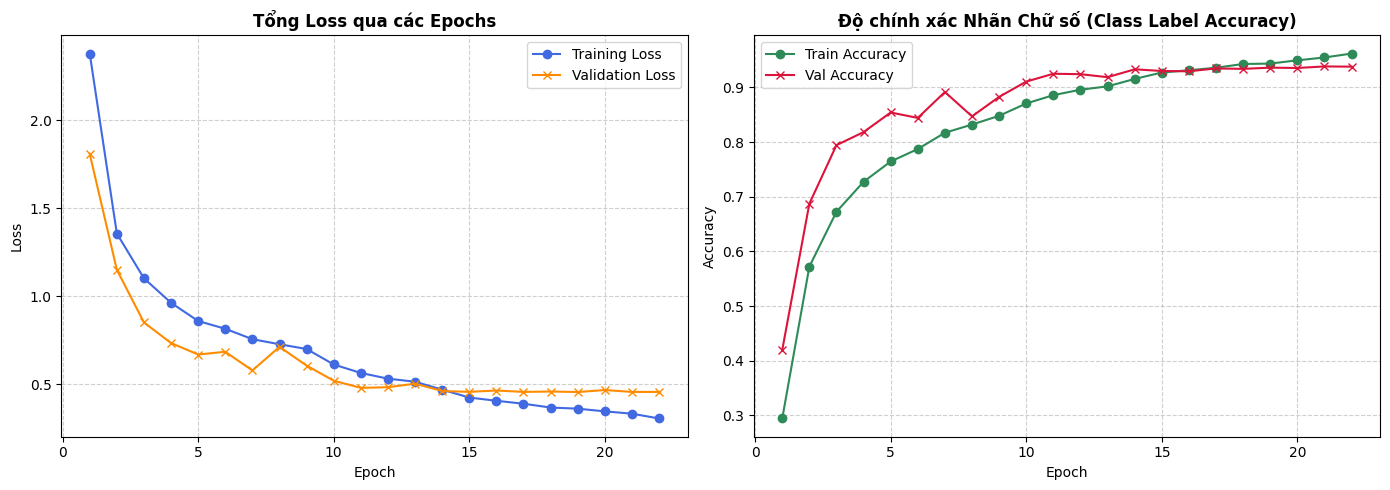

In [64]:
# --- CELL VẼ BIỂU ĐỒ THỐNG KÊ QUÁ TRÌNH TRAIN ---
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs_range = range(1, len(history.history['loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Đồ thị 1: Tổng Loss (Total Loss) và Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history['loss'], label='Training Loss', color='royalblue', marker='o')
    plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='darkorange', marker='x')
    plt.title('Tổng Loss qua các Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Đồ thị 2: Accuracy của nhánh phân lớp Class Label
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history['class_label_accuracy'], label='Train Accuracy', color='seagreen', marker='o')
    plt.plot(epochs_range, history.history['val_class_label_accuracy'], label='Val Accuracy', color='crimson', marker='x')
    plt.title('Độ chính xác Nhãn Chữ số (Class Label Accuracy)', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

📸 [ẢNH 1/10] - INDEX: 12217 | FILE: 12218.png
📊 Số chữ số thực tế: 1
   ↳ Vị trí 1: Thực tế = 3 | Dự đoán = 3 (100.00%)
------------------------------------------------------------
📸 [ẢNH 2/10] - INDEX: 9213 | FILE: 9214.png
📊 Số chữ số thực tế: 2
   ↳ Vị trí 1: Thực tế = 3 | Dự đoán = 3 (100.00%)
   ↳ Vị trí 2: Thực tế = 4 | Dự đoán = 4 (100.00%)
------------------------------------------------------------
📸 [ẢNH 3/10] - INDEX: 9620 | FILE: 9621.png
📊 Số chữ số thực tế: 1
   ↳ Vị trí 1: Thực tế = 9 | Dự đoán = 9 (100.00%)
------------------------------------------------------------
📸 [ẢNH 4/10] - INDEX: 10984 | FILE: 10985.png
📊 Số chữ số thực tế: 2
   ↳ Vị trí 1: Thực tế = 1 | Dự đoán = 1 (100.00%)
   ↳ Vị trí 2: Thực tế = 1 | Dự đoán = 1 (100.00%)
------------------------------------------------------------
📸 [ẢNH 5/10] - INDEX: 178 | FILE: 179.png
📊 Số chữ số thực tế: 1
   ↳ Vị trí 1: Thực tế = 3 | Dự đoán = 3 (99.90%)
------------------------------------------------------------
📸 

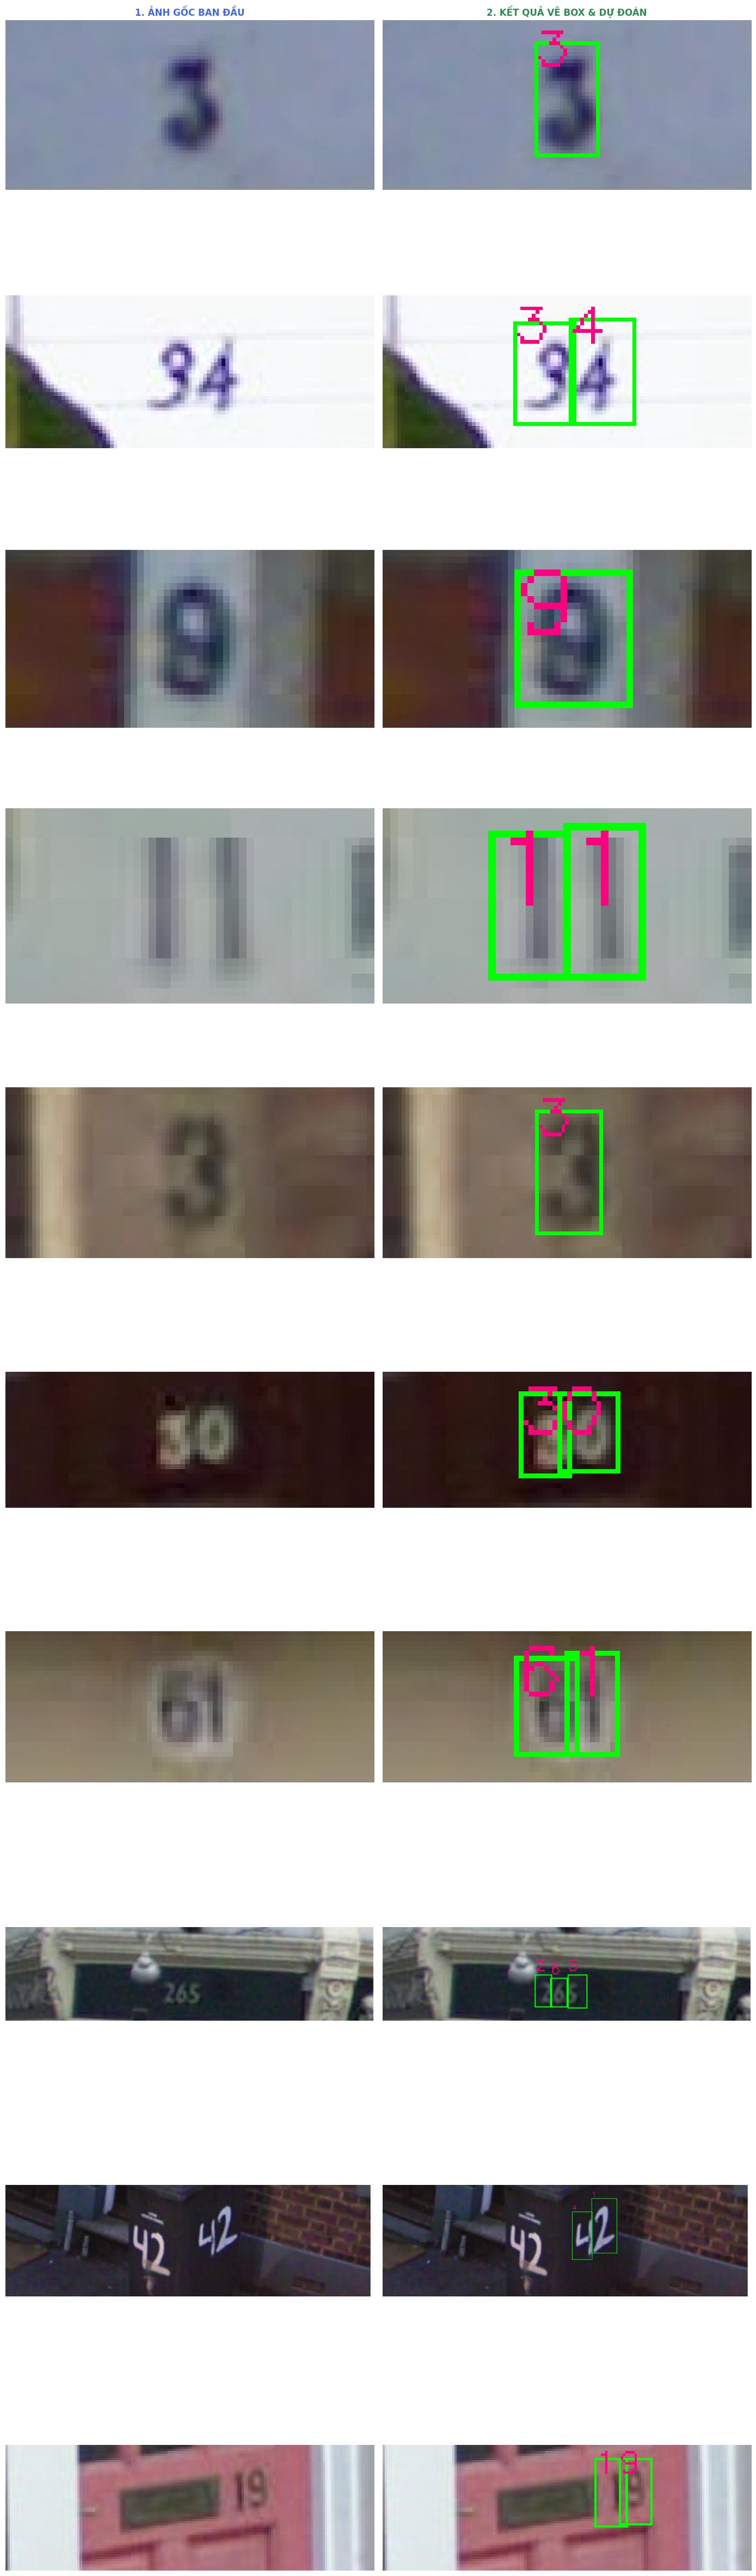

In [72]:
# --- CELL TEST HOÀN CHỈNH: ĐỐI CHIẾU 10 ẢNH NGẪU NHIÊN CÙNG LÚC ---
import numpy as np
import h5py
import cv2
import matplotlib.pyplot as plt
import os

def plot_10_random_test_images(test_mat_path, test_dir_path, model):
    """
    Chọn ngẫu nhiên 10 ảnh test riêng biệt, in thông số độ tự tin chi tiết ra màn hình
    và hiển thị một lưới ảnh đối chiếu song song (Ảnh gốc vs Ảnh dự đoán).
    """
    num_test_samples = 10
    
    with h5py.File(test_mat_path, 'r') as f:
        total_test_images = len(f['digitStruct']['bbox'])
        
        # Chọn ngẫu nhiên 10 chỉ mục ảnh không trùng nhau
        random_indices = np.random.choice(total_test_images, size=num_test_samples, replace=False)
        
        fig, axes = plt.subplots(num_test_samples, 2, figsize=(14, 5 * num_test_samples))
        
        for idx, image_index in enumerate(random_indices):
            img_name = get_name(image_index, f)
            img_path = os.path.join(test_dir_path, img_name)
            
            if not os.path.exists(img_path):
                print(f"❌ Không tìm thấy ảnh test tại: {img_path}")
                continue
                
            img_original = cv2.imread(img_path)
            h_orig, w_orig = img_original.shape[:2]
            img_predicted = img_original.copy()
            
            box_data = get_box_data(image_index, f)
            num_digits = len(box_data['label'])
            
            # --- IN THỐNG KÊ CHI TIẾT RA MÀN HÌNH ---
            print(f"📸 [ẢNH {idx + 1}/10] - INDEX: {image_index} | FILE: {img_name}")
            print(f"📊 Số chữ số thực tế: {num_digits}")
            
            # Quét qua từng chữ số trong ảnh hiện tại
            for j in range(num_digits):
                top, left = box_data['top'][j], box_data['left'][j]
                width, height = box_data['width'][j], box_data['height'][j]
                
                xmin, ymin = max(0, left), max(0, top)
                xmax, ymax = min(w_orig, left + width), min(h_orig, top + height)
                
                pad = 8
                crop_xmin = max(0, xmin - pad)
                crop_ymin = max(0, ymin - pad)
                crop_xmax = min(w_orig, xmax + pad)
                crop_ymax = min(h_orig, ymax + pad)
                
                img_gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)
                crop_img = img_gray[crop_ymin:crop_ymax, crop_xmin:crop_xmax]
                
                if crop_img.size == 0:
                    continue
                    
                crop_resized = cv2.resize(crop_img, (64, 64))
                crop_input = np.array(crop_resized, dtype=np.float32) / 255.0
                crop_input = np.expand_dims(crop_input, axis=(0, -1))
                
                # Model dự đoán nhãn và tọa độ bounding box
                pred_bbox, pred_class = model.predict(crop_input, verbose=0)
                digit = np.argmax(pred_class[0])
                confidence = pred_class[0, digit]
                
                # Chuẩn hóa nhãn nhãn thực tế giống như lúc hiển thị
                true_label = box_data['label'][j] if box_data['label'][j] != 10 else 0
                print(f"   ↳ Vị trí {j+1}: Thực tế = {true_label} | Dự đoán = {digit} ({confidence * 100:.2f}%)")
                
                # Giải mã tọa độ bounding box tương đối về pixel ảnh gốc
                p_xmin, p_ymin, p_xmax, p_ymax = pred_bbox[0]
                crop_h, crop_w = crop_img.shape[:2]
                
                final_xmin = int((p_xmin * crop_w) + crop_xmin)
                final_ymin = int((p_ymin * crop_h) + crop_ymin)
                final_xmax = int((p_xmax * crop_w) + crop_xmin)
                final_ymax = int((p_ymax * crop_h) + crop_ymin)
                
                # Vẽ khung màu xanh lá lên ảnh dự đoán
                cv2.rectangle(img_predicted, (final_xmin, final_ymin), (final_xmax, final_ymax), (0, 255, 0), 1)
                # Ghi số màu hồng cánh sen
                cv2.putText(img_predicted, f"{digit}", (final_xmin, max(12, final_ymin - 4)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (128, 0, 255), 1)
                
            print("-" * 60)
            
            # --- ĐƯA ẢNH VÀO LƯỚI HIỂN THỊ (GRID) ---
            # Cột 1: Ảnh gốc ban đầu
            img_orig_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
            axes[idx, 0].imshow(img_orig_rgb)
            axes[idx, 0].axis('off')
            if idx == 0:
                axes[idx, 0].set_title("1. ẢNH GỐC BAN ĐẦU", fontsize=12, fontweight='bold', color='royalblue')
            
            # Cột 2: Kết quả vẽ box và dự đoán nhãn
            img_pred_rgb = cv2.cvtColor(img_predicted, cv2.COLOR_BGR2RGB)
            axes[idx, 1].imshow(img_pred_rgb)
            axes[idx, 1].axis('off')
            if idx == 0:
                axes[idx, 1].set_title("2. KẾT QUẢ VẼ BOX & DỰ ĐOÁN", fontsize=12, fontweight='bold', color='seagreen')
        
        plt.tight_layout()
        plt.show()

# --- ĐƯỜNG DẪN CONFIG ---
TEST_DIR = '/kaggle/input/datasets/organizations/stanfordu/street-view-house-numbers/test/test'
TEST_MAT = '/kaggle/input/datasets/organizations/stanfordu/street-view-house-numbers/test_digitStruct.mat'

plot_10_random_test_images(TEST_MAT, TEST_DIR, model)